# BEAD RF — SHAP, Ablation, and Feature Importance Analysis
Loads the pre-saved enriched dataset, trains the final integrated model, and produces:
1. Feature ablation table
2. Normalized feature importance table (RF Gini, SHAP, LIME)
3. SHAP beeswarm summary plot

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── Load pre-saved enriched dataset ─────────────────────────────────────────
df_raw = pd.read_csv('fp_enriched.csv')
df_raw['log_funding'] = np.log1p(df_raw['funding_per_location'])

low  = df_raw['funding_per_location'].quantile(0.025)
high = df_raw['funding_per_location'].quantile(0.975)
df = df_raw[(df_raw['funding_per_location'] >= low) & (df_raw['funding_per_location'] <= high)].copy()

print(f'Trimmed dataset: {df.shape[0]} projects')

Trimmed dataset: 5429 projects


In [2]:

# ── Feature set (final integrated model, 20 features) ───────────────────────
FEATURE_COLS = [
    # Technology mix (fraction of locations per tech)
    'frac_tech_40',
    'frac_tech_50',
    'frac_tech_61',
    'frac_tech_71',
    # Project-level
    'miles_per_location',
    'pct_aerial',
    'pct_cai',
    'n_total',
    # Competition (Dec 2024 NBM) — specific tech types only
    'frac_fiber_comp',
    'frac_cable_comp',
    'frac_fw_comp',
    # ISP incumbency
    'prov_coverage',
    'frac_present_at_location',
    # Geography — county-level weighted means
    'POPDEN_RUR_wmean',
    'POPDEN_COU_wmean',
    'rucc_code_wmean',
    'poverty_rate_wmean',
    # Prior-service proximity
    'no_prior_presence_frac',
    'nearest_mi_served_same_isp',
    'nearest_mi_served_any',
]

pretty_names_map = {
    'frac_tech_40':             'frac_tech_40',
    'frac_tech_50':             'frac_tech_50',
    'frac_tech_61':             'frac_tech_61 (fiber)',
    'frac_tech_71':             'frac_tech_71 (FW)',
    'miles_per_location':       'miles_per_location',
    'pct_aerial':               'pct_aerial',
    'pct_cai':                  'pct_cai',
    'n_total':                  'n_total',
    'frac_fiber_comp':          'frac_fiber_comp',
    'frac_cable_comp':          'frac_cable_comp',
    'frac_fw_comp':             'frac_fw_comp',
    'prov_coverage':            'prov_coverage',
    'frac_present_at_location': 'frac_present_at_location',
    'POPDEN_RUR_wmean':         'POPDEN_RUR_wmean',
    'POPDEN_COU_wmean':         'POPDEN_COU_wmean',
    'rucc_code_wmean':          'rucc_code_wmean',
    'poverty_rate_wmean':       'poverty_rate_wmean',
    'no_prior_presence_frac':   'no_prior_presence_frac',
    'nearest_mi_served_same_isp': 'nearest_mi_served_same_isp',
    'nearest_mi_served_any':    'nearest_mi_served_any',
}

X = df[FEATURE_COLS].fillna(0)
y = df['log_funding']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ── Final model ──────────────────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=0.3,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

baseline_r2   = r2_score(y_test, y_pred)
baseline_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
baseline_mae  = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(rf, X, y, cv=kf, scoring='r2')

print(f'Features: {len(FEATURE_COLS)}')
print(f'=== Baseline Model ===')
print(f'Test R²  (log): {baseline_r2:.4f}')
print(f'CV R²   (log): {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'RMSE (real $): ${baseline_rmse:,.0f}')
print(f'MAE  (real $): ${baseline_mae:,.0f}')


Features: 20
=== Baseline Model ===
Test R²  (log): 0.7257
CV R²   (log): 0.7260 ± 0.0161
RMSE (real $): $3,482
MAE  (real $): $1,835


## 1. Feature Ablation

In [3]:
ablation_results = []

for feat in FEATURE_COLS:
    cols_reduced = [c for c in FEATURE_COLS if c != feat]
    X_tr = X_train[cols_reduced]
    X_te = X_test[cols_reduced]

    rf_ab = RandomForestRegressor(
        n_estimators=200, min_samples_split=2, min_samples_leaf=1,
        max_features=0.3, max_depth=20, random_state=42, n_jobs=-1
    )
    rf_ab.fit(X_tr, y_train)
    yp = rf_ab.predict(X_te)

    r2   = r2_score(y_test, yp)
    rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(yp)))
    mae  = mean_absolute_error(np.expm1(y_test), np.expm1(yp))

    ablation_results.append({
        'feature': feat,
        'r2':      r2,
        'delta_r2': r2 - baseline_r2,
        'rmse':    rmse,
        'mae':     mae,
    })
    print(f'  {feat:35s}  R²={r2:.4f}  ΔR²={r2-baseline_r2:+.4f}  RMSE=${rmse:,.0f}')

abl_df = pd.DataFrame(ablation_results).sort_values('delta_r2')
print(f'\nBaseline Test R² = {baseline_r2:.4f}')

  frac_tech_40                         R²=0.7264  ΔR²=+0.0007  RMSE=$3,499


  frac_tech_50                         R²=0.7265  ΔR²=+0.0008  RMSE=$3,504


  frac_tech_61                         R²=0.7256  ΔR²=-0.0001  RMSE=$3,496


  frac_tech_71                         R²=0.7251  ΔR²=-0.0006  RMSE=$3,490


  miles_per_location                   R²=0.6957  ΔR²=-0.0301  RMSE=$3,605


...

  rucc_code_wmean                      R²=0.7251  ΔR²=-0.0006  RMSE=$3,501


  poverty_rate_wmean                   R²=0.7258  ΔR²=+0.0001  RMSE=$3,488


  no_prior_presence_frac               R²=0.7278  ΔR²=+0.0020  RMSE=$3,473


  nearest_mi_served_same_isp           R²=0.7241  ΔR²=-0.0017  RMSE=$3,495


  nearest_mi_served_any                R²=0.7283  ΔR²=+0.0026  RMSE=$3,475

Baseline Test R² = 0.7257


In [4]:
# ── LaTeX: Ablation table ────────────────────────────────────────────────────
print(r"""\begin{table*}[ht]
\centering""")
print(f"""\\caption{{Feature ablation results. Baseline Test $R^2 = {baseline_r2:.4f}$.}}
\\label{{tab:ablation}}
\\begin{{tabularx}}{{\\textwidth}}{{>{{\\ttfamily}}Xcccc}}
\\toprule
\\textbf{{Feature}} & \\textbf{{Test $R^2$}} & \\textbf{{$\\Delta R^2$}} & \\textbf{{RMSE (\\$)}} & \\textbf{{MAE (\\$)}} \\\\
\\midrule""")

neg_rows = abl_df[abl_df['delta_r2'] <= 0].sort_values('delta_r2')
pos_rows = abl_df[abl_df['delta_r2'] > 0].sort_values('delta_r2', ascending=False)

for _, row in neg_rows.iterrows():
    feat = row['feature'].replace('_', '\\_')
    sign = '+' if row['delta_r2'] >= 0 else '-'
    print(f"{feat:45s} & {row['r2']:.4f} & ${row['delta_r2']:+.4f}$ & "
          f"{row['rmse']:,.0f} & {row['mae']:,.0f} \\\\")

if not pos_rows.empty:
    print(r"\hhline{=====}")
    for _, row in pos_rows.iterrows():
        feat = row['feature'].replace('_', '\\_')
        print(f"{feat:45s} & {row['r2']:.4f} & ${row['delta_r2']:+.4f}$ & "
              f"{row['rmse']:,.0f} & {row['mae']:,.0f} \\\\")

print(r"""\bottomrule
\end{tabularx}
\end{table*}""")

\begin{table*}[ht]
\centering
\caption{Feature ablation results. Baseline Test $R^2 = 0.7257$.}
\label{tab:ablation}
\begin{tabularx}{\textwidth}{>{\ttfamily}Xcccc}
\toprule
\textbf{Feature} & \textbf{Test $R^2$} & \textbf{$\Delta R^2$} & \textbf{RMSE (\$)} & \textbf{MAE (\$)} \\
\midrule
miles\_per\_location                          & 0.6957 & $-0.0301$ & 3,605 & 1,985 \\
n\_total                                      & 0.7110 & $-0.0147$ & 3,652 & 1,889 \\
POPDEN\_RUR\_wmean                            & 0.7126 & $-0.0131$ & 3,648 & 1,915 \\
POPDEN\_COU\_wmean                            & 0.7226 & $-0.0031$ & 3,451 & 1,850 \\
frac\_present\_at\_location                   & 0.7230 & $-0.0027$ & 3,498 & 1,863 \\
pct\_aerial                                   & 0.7240 & $-0.0017$ & 3,494 & 1,863 \\
nearest\_mi\_served\_same\_isp                & 0.7241 & $-0.0017$ & 3,495 & 1,856 \\
frac\_tech\_71                                & 0.7251 & $-0.0006$ & 3,490 & 1,848 \\
rucc\_code\_wmean     

## 2. SHAP Analysis

In [5]:
try:
    import shap
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'shap', '-q'])
    import shap

print(f'SHAP version: {shap.__version__}')

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
print(f'SHAP values shape: {shap_values.shape}')

SHAP version: 0.52.0


SHAP values shape: (1629, 20)


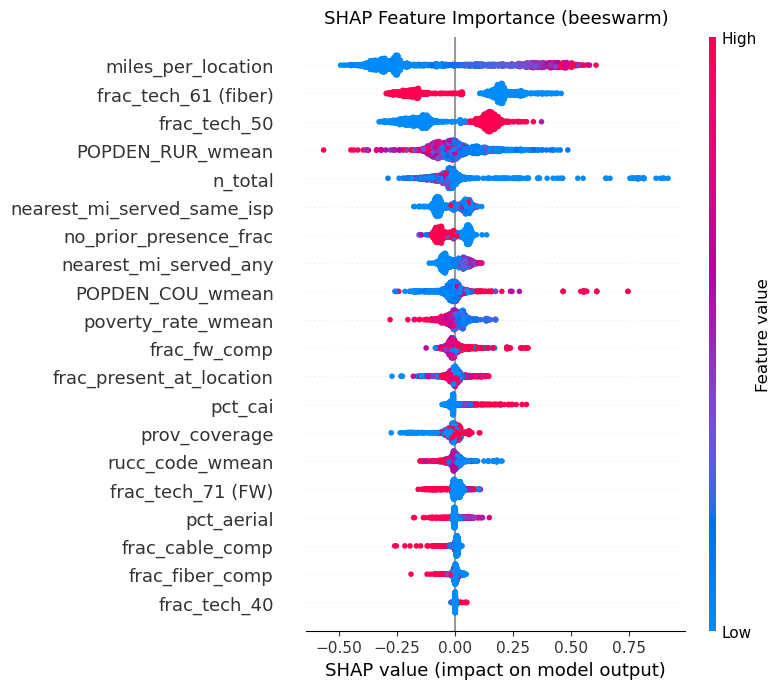

Saved: shap_beeswarm.pdf / shap_beeswarm.png


In [6]:

# ── SHAP beeswarm summary plot ───────────────────────────────────────────────
plot_names = [pretty_names_map[c] for c in FEATURE_COLS]

fig, ax = plt.subplots(figsize=(8, 7))
shap.summary_plot(
    shap_values, X_test,
    feature_names=plot_names,
    show=False,
    plot_size=None,
    color_bar_label='Feature value'
)
plt.title('SHAP Feature Importance (beeswarm)', fontsize=13, pad=10)
plt.tight_layout()
plt.savefig('shap_beeswarm.pdf', bbox_inches='tight', dpi=150)
plt.savefig('shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: shap_beeswarm.pdf / shap_beeswarm.png')


## 3. LIME Analysis

In [7]:
try:
    import lime
    import lime.lime_tabular
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'lime', '-q'])
    import lime
    import lime.lime_tabular

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=FEATURE_COLS,
    mode='regression',
    random_state=42
)

# Sample 200 test instances (LIME is slow)
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test), size=min(200, len(X_test)), replace=False)
X_test_arr  = X_test.values

lime_importances = np.zeros(len(FEATURE_COLS))

for i, idx in enumerate(sample_idx):
    exp = lime_explainer.explain_instance(
        X_test_arr[idx],
        rf.predict,
        num_features=len(FEATURE_COLS),
    )
    for feat_name, weight in exp.as_list():
        # LIME feature names may include inequalities; match by FEATURE_COLS substring
        for j, col in enumerate(FEATURE_COLS):
            if col in feat_name:
                lime_importances[j] += abs(weight)
                break
    if (i+1) % 50 == 0:
        print(f'  LIME: {i+1}/{len(sample_idx)} done')

lime_importances /= len(sample_idx)
print('LIME done.')

  LIME: 50/200 done


  LIME: 100/200 done


  LIME: 150/200 done


  LIME: 200/200 done
LIME done.


## 4. Normalized Importance Comparison Table

In [8]:
# ── Collect and normalize ────────────────────────────────────────────────────
gini_raw = rf.feature_importances_                       # already sum to 1
shap_raw = np.abs(shap_values).mean(axis=0)              # mean |SHAP|
lime_raw = lime_importances

# Normalize each to sum to 1
def norm(arr):
    s = arr.sum()
    return arr / s if s > 0 else arr

gini_norm = norm(gini_raw)
shap_norm = norm(shap_raw)
lime_norm = norm(lime_raw)

importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'gini':    gini_norm,
    'shap':    shap_norm,
    'lime':    lime_norm,
}).sort_values('shap', ascending=False)

print(importance_df.to_string(index=False))

                   feature     gini     shap     lime
        miles_per_location 0.189551 0.239916 0.261476
              frac_tech_61 0.082394 0.166718 0.271431
              frac_tech_50 0.114274 0.129521 0.102458
          POPDEN_RUR_wmean 0.076639 0.065186 0.056997
                   n_total 0.082163 0.059774 0.016269
nearest_mi_served_same_isp 0.046064 0.048038 0.037560
    no_prior_presence_frac 0.031244 0.044995 0.035478
     nearest_mi_served_any 0.041134 0.033894 0.012052
          POPDEN_COU_wmean 0.080595 0.033398 0.006847
        poverty_rate_wmean 0.041745 0.025425 0.020785
              frac_fw_comp 0.039304 0.024199 0.005828
  frac_present_at_location 0.026002 0.022805 0.003644
                   pct_cai 0.014387 0.020029 0.088751
             prov_coverage 0.031415 0.019996 0.006152
           rucc_code_wmean 0.031788 0.017967 0.008515
              frac_tech_71 0.018654 0.016783 0.028268
                pct_aerial 0.019604 0.014158 0.008356
           frac_cable_comp 0

In [9]:
# ── LaTeX: Normalized importance table ──────────────────────────────────────
print(r"""\begin{table}[h]
  \centering
  \caption{Normalized feature importance from three methods}
  \label{tab:importance_comparison}
  \begin{tabular}{lccc}
  \hline
  \textbf{Feature} & \textbf{RF Gini} & \textbf{SHAP} & \textbf{LIME} \\\\
  \hline""")

for _, row in importance_df.iterrows():
    feat = '\\texttt{' + row['feature'].replace('_', '\\_') + '}'
    print(f"  {feat:55s} & {row['gini']:.3f} & {row['shap']:.3f} & {row['lime']:.3f} \\\\")

print(r"""  \hline
  \end{tabular}
\end{table}""")

\begin{table}[h]
  \centering
  \caption{Normalized feature importance from three methods}
  \label{tab:importance_comparison}
  \begin{tabular}{lccc}
  \hline
  \textbf{Feature} & \textbf{RF Gini} & \textbf{SHAP} & \textbf{LIME} \\\\
  \hline
  \texttt{miles\_per\_location}                           & 0.190 & 0.240 & 0.261 \\
  \texttt{frac\_tech\_61}                                 & 0.082 & 0.167 & 0.271 \\
  \texttt{frac\_tech\_50}                                 & 0.114 & 0.130 & 0.102 \\
  \texttt{POPDEN\_RUR\_wmean}                             & 0.077 & 0.065 & 0.057 \\
  \texttt{n\_total}                                       & 0.082 & 0.060 & 0.016 \\
  \texttt{nearest\_mi\_served\_same\_isp}                 & 0.046 & 0.048 & 0.038 \\
  \texttt{no\_prior\_presence\_frac}                      & 0.031 & 0.045 & 0.035 \\
  \texttt{nearest\_mi\_served\_any}                       & 0.041 & 0.034 & 0.012 \\
  \texttt{POPDEN\_COU\_wmean}                             & 0.081 & 0.033 & 

In [10]:
# ── Save importance data to CSV ──────────────────────────────────────────────
importance_df.to_csv('feature_importances.csv', index=False)
abl_df.to_csv('ablation_results.csv', index=False)
print('Saved feature_importances.csv and ablation_results.csv')

Saved feature_importances.csv and ablation_results.csv
